# 01 — EDA & Honest Churn Base Rate
**RetainIQ India (Day 4).** Exploratory view of the BharatConnect data with the honest base churn rate. All figures computed live from the DuckDB feature layer.

In [1]:
import sys, duckdb, pandas as pd
sys.path.insert(0, '../src')
pd.set_option('display.width', 120)
DB = '../data/processed/retainiq.duckdb'
con = duckdb.connect(DB, read_only=True)

## Base churn rate (the number every later metric is compared against)

In [2]:
base = con.execute('SELECT AVG(churned::INT) FROM feature_customer').fetchone()[0]
print(f'Base churn rate: {base:.4f}  ({base:.1%})')

Base churn rate: 0.2654  (26.5%)


## Churn by contract, payment, internet

In [3]:
for col in ['contract_type','payment_method','internet_type']:
    print(con.execute(f'''SELECT {col}, COUNT(*) customers, ROUND(AVG(churned::INT),3) churn_rate
        FROM feature_customer GROUP BY {col} ORDER BY churn_rate DESC''').df().to_string(index=False)); print()

 contract_type  customers  churn_rate
Month-to-month       3875       0.427
      One year       1473       0.113
      Two year       1695       0.028

           payment_method  customers  churn_rate
         Electronic check       2365       0.453
             Mailed check       1612       0.191
Bank transfer (automatic)       1544       0.167
  Credit card (automatic)       1522       0.152

internet_type  customers  churn_rate
  Fiber optic       3096       0.419
          DSL       2421       0.190
           No       1526       0.074



## Churn by tenure bucket and adoption depth

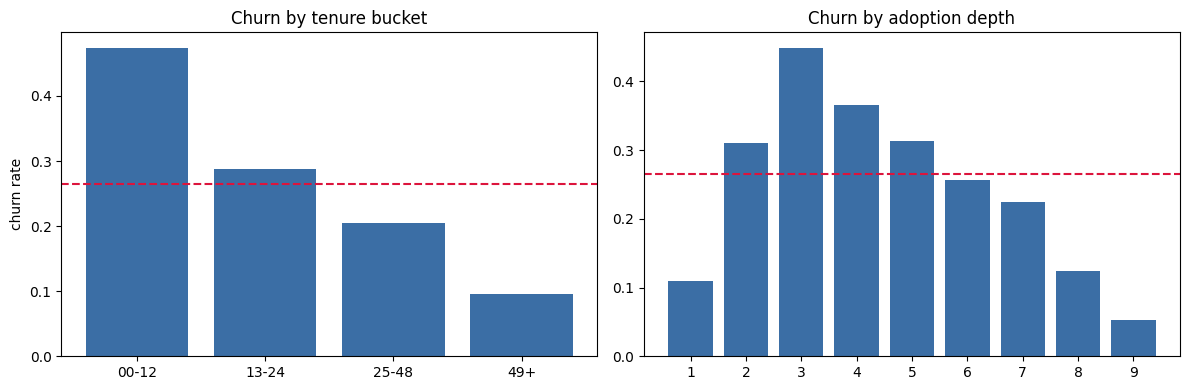

In [4]:
import matplotlib.pyplot as plt
d = con.execute('''SELECT tenure_bucket, ROUND(AVG(churned::INT),3) churn_rate
   FROM feature_customer GROUP BY tenure_bucket ORDER BY tenure_bucket''').df()
s = con.execute('''SELECT services_held, ROUND(AVG(churned::INT),3) churn_rate
   FROM feature_customer GROUP BY services_held ORDER BY services_held''').df()
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(d.tenure_bucket, d.churn_rate, color='#3b6ea5'); ax[0].axhline(base, ls='--', color='crimson')
ax[0].set_title('Churn by tenure bucket'); ax[0].set_ylabel('churn rate')
ax[1].bar(s.services_held.astype(str), s.churn_rate, color='#3b6ea5'); ax[1].axhline(base, ls='--', color='crimson')
ax[1].set_title('Churn by adoption depth'); plt.tight_layout(); plt.show()

**Read:** churn falls steeply with tenure (47% in the first year → ~10% after 4 years) and is highly non-linear in adoption depth. These motivate survival analysis (Day 5) and the tenure/contract features.

In [5]:
con.close()